#  Notebook 02: Feature Engineering — WoE Binning & IV Selection
**BFSI Credit Risk Scorecard — Canadian Banking**  
Pipeline: `data_preprocessing` → **`woe_binning`** → `model_training`

## Overview
Weight of Evidence (WoE) transformation is the industry-standard feature
engineering technique for logistic regression scorecards at Canadian banks.

**Why WoE?**
- Converts non-linear relationships to linear (required for LR)
- Handles missing values naturally (separate "Missing" bin)
- Enforces monotonicity for scorecard interpretability
- Produces Information Value (IV) for automated feature selection
- OSFI E-23: creates auditable, interpretable feature transformations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "../src")

from data_preprocessing import load_hmeq, handle_missing_values, winsorize_features, encode_categoricals, temporal_split
from woe_binning import WoETransformer, plot_woe_bins, plot_iv_summary

import warnings; warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
NAVY = "#003366"

## 1. Load & Clean Data

In [2]:
df_raw  = load_hmeq("../data/raw/hmeq.csv")
df_clean= handle_missing_values(df_raw, "BAD", missing_threshold=0.60)
df_clean= winsorize_features(df_clean, "BAD")
df_clean, enc_map = encode_categoricals(df_clean, "BAD")

X_train, X_val, X_test, y_train, y_val, y_test = temporal_split(df_clean, "BAD")
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Default rates — Train: {y_train.mean():.2%} | Val: {y_val.mean():.2%} | Test: {y_test.mean():.2%}")

2026-03-25 20:11:38,998 — INFO — Loading HMEQ dataset from ../data/raw/hmeq.csv
2026-03-25 20:11:39,029 — INFO — Loaded 5,960 rows × 13 columns
2026-03-25 20:11:39,033 — INFO — Dropped 0 rows with missing target
2026-03-25 20:11:39,055 — INFO — Missing value handling complete. Shape: (5960, 20)
2026-03-25 20:11:39,075 — INFO — Winsorization complete for 10 numeric features
2026-03-25 20:11:39,088 — INFO — Encoded 2 categorical features
2026-03-25 20:11:39,624 — INFO — Split sizes — Train: 4,172 | Val: 596 | Test: 1,192
2026-03-25 20:11:39,624 — INFO — Default rates — Train: 19.92% | Val: 19.97% | Test: 19.97%


Train: (4172, 19), Val: (596, 19), Test: (1192, 19)
Default rates — Train: 19.92% | Val: 19.97% | Test: 19.97%


## 2. Fit WoE Transformer (on Train ONLY — never on test)

In [3]:
woe_transformer = WoETransformer(n_bins=10, enforce_monotonicity=True, iv_minimum=0.02)
X_train_woe = woe_transformer.fit_transform(X_train, y_train)
X_val_woe   = woe_transformer.transform(X_val)
X_test_woe  = woe_transformer.transform(X_test)

print(f"\nWoE features shape: {X_train_woe.shape}")
print(f"\nInformation Value Table:")
print(woe_transformer.iv_table_.to_string(index=False))

2026-03-25 20:11:39,642 — INFO — Fitting WoE binners for 19 features...
2026-03-25 20:11:40,081 — INFO — WoE fitting complete. Selected 3 features (IV ≥ 0.02)



WoE features shape: (4172, 3)

Information Value Table:
        Feature     IV                   Strength  N_Bins
         DELINQ 2.8064 Suspicious (check leakage)       5
          DEROG 1.5064 Suspicious (check leakage)       5
        DEBTINC 0.7867 Suspicious (check leakage)       7
          CLAGE 0.0096                    Useless       3
  CLAGE_MISSING 0.0073                    Useless       2
            JOB 0.0066                    Useless       7
    YOJ_MISSING 0.0061                    Useless       2
            YOJ 0.0041                    Useless       3
  DEROG_MISSING 0.0035                    Useless       2
           NINQ 0.0026                    Useless       7
           LOAN 0.0024                    Useless       3
        MORTDUE 0.0023                    Useless       6
           CLNO 0.0011                    Useless       3
          VALUE 0.0010                    Useless       2
         REASON 0.0009                    Useless       3
DEBTINC_MISSING

## 3. IV Summary Chart

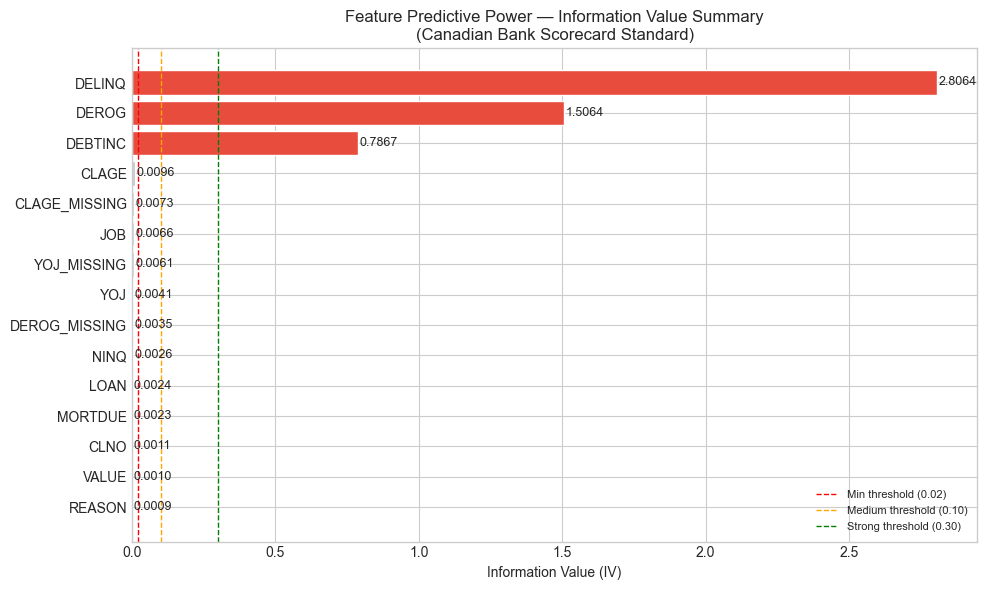

In [4]:
fig = plot_iv_summary(woe_transformer.iv_table_, top_n=15)
plt.savefig("../reports/output/02_iv_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. WoE Bin Charts for Top Features

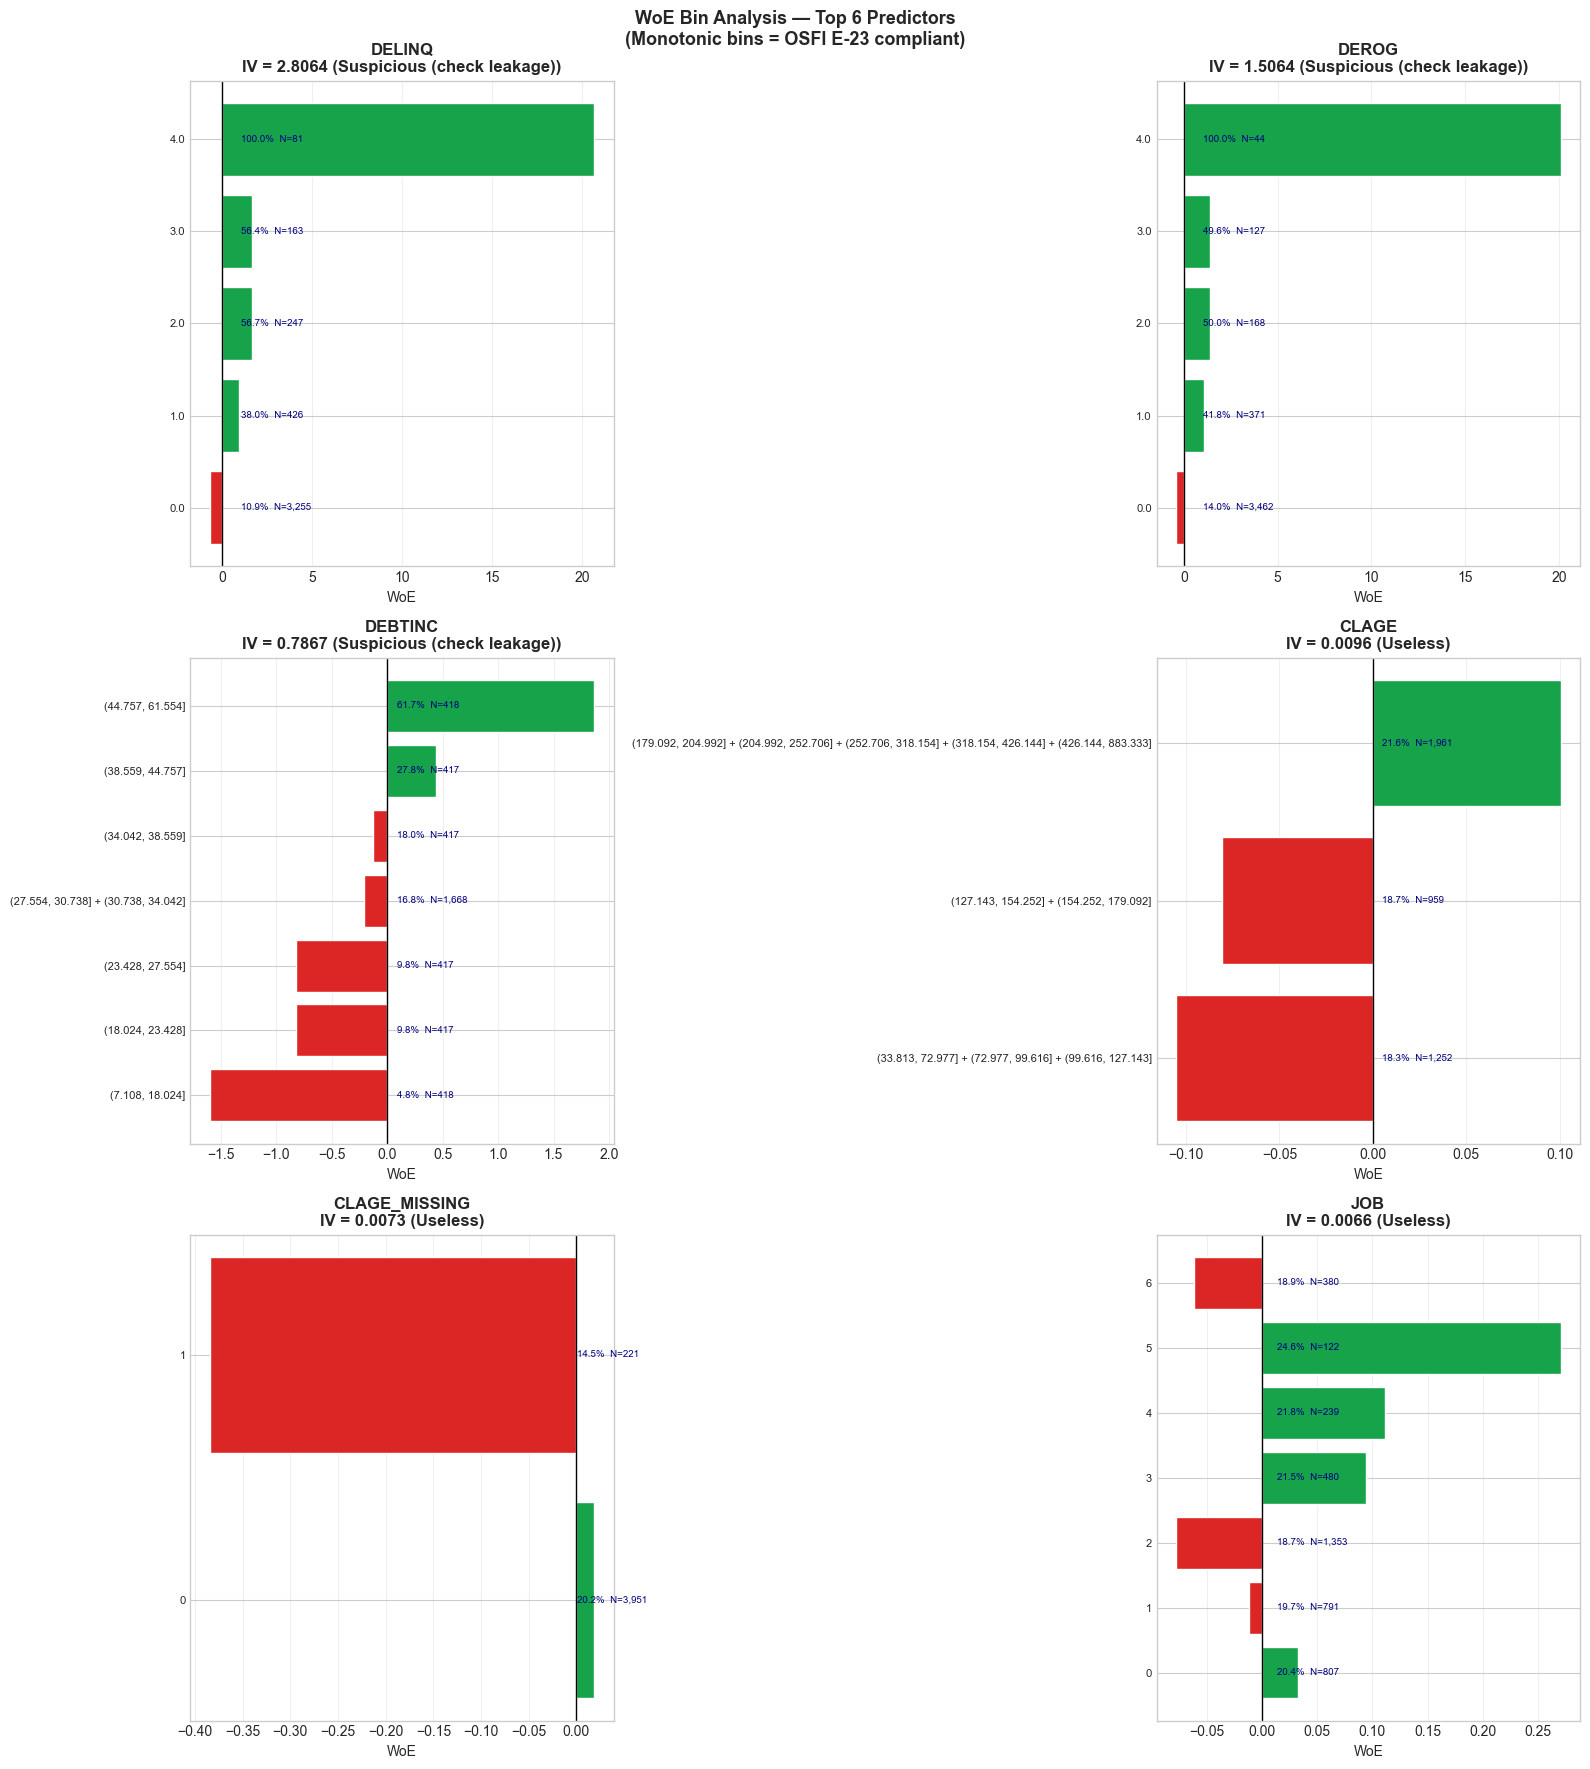

In [5]:
top_features = woe_transformer.iv_table_.head(6)["Feature"].tolist()

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, fname in enumerate(top_features):
    binner = woe_transformer.binners_[fname]
    stats  = binner.bin_stats_
    ax     = axes[i]
    colors = ["#dc2626" if w < 0 else "#16a34a" for w in stats["WoE"]]
    ax.barh(range(len(stats)), stats["WoE"], color=colors, edgecolor="white")
    ax.set_yticks(range(len(stats)))
    ax.set_yticklabels(stats["Bin"].values, fontsize=8)
    ax.axvline(0, color="black", lw=1)
    ax.set_xlabel("WoE")
    ax.set_title(f"{fname}\nIV = {binner.iv_:.4f} ({woe_transformer.iv_table_[woe_transformer.iv_table_['Feature']==fname]['Strength'].values[0]})",
                 fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    # Add event rate labels
    for j, row in stats.iterrows():
        ax.text(stats["WoE"].max()*0.05, j, f"{row['EventRate']*100:.1f}%  N={row['N']:,}",
                va="center", fontsize=7, color="navy")

plt.suptitle("WoE Bin Analysis — Top 6 Predictors\n(Monotonic bins = OSFI E-23 compliant)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/output/02_woe_bins_top6.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. WoE Correlation Check (Multicollinearity)


Highly correlated WoE feature pairs (|r| > 0.70):
  None — WoE features are sufficiently uncorrelated ✓


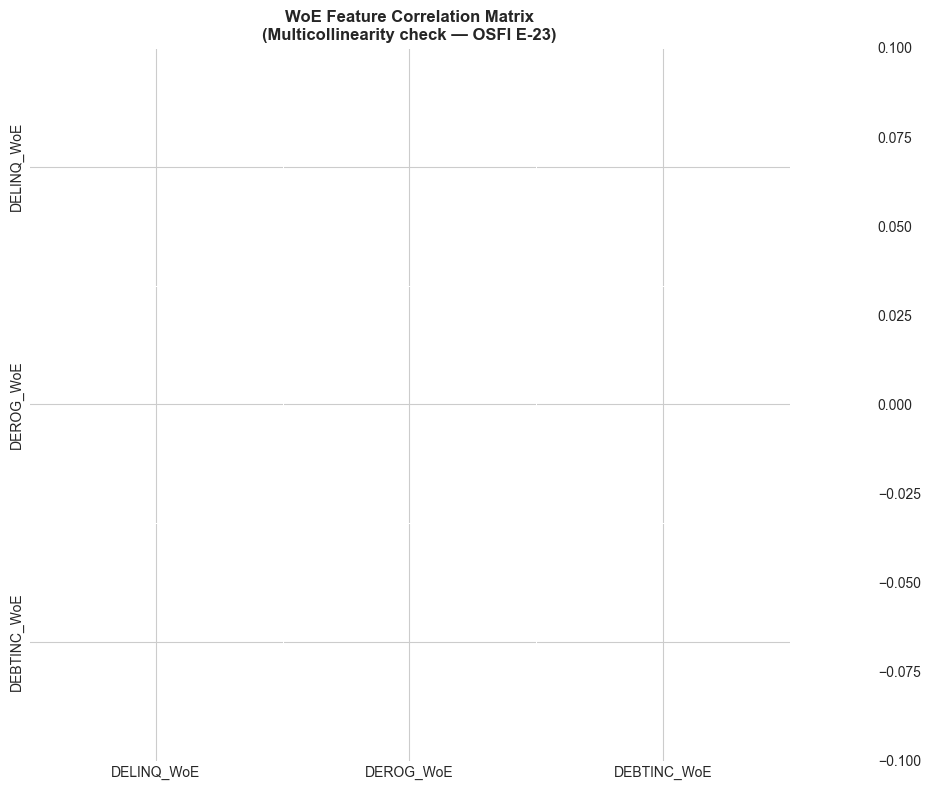

In [6]:
import seaborn as sns
woe_corr = X_train_woe.corr()
high_corr_pairs = []
for i in range(len(woe_corr.columns)):
    for j in range(i+1, len(woe_corr.columns)):
        r = woe_corr.iloc[i, j]
        if abs(r) > 0.70:
            high_corr_pairs.append((woe_corr.columns[i], woe_corr.columns[j], round(r, 4)))

print(f"\nHighly correlated WoE feature pairs (|r| > 0.70):")
if high_corr_pairs:
    for f1, f2, r in high_corr_pairs:
        print(f"  {f1} ↔ {f2}: r = {r}")
else:
    print("  None — WoE features are sufficiently uncorrelated ✓")

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(woe_corr, dtype=bool))
sns.heatmap(woe_corr, mask=mask, cmap="RdBu_r", center=0, annot=len(woe_corr) < 12,
            fmt=".2f", ax=ax, linewidths=0.5, annot_kws={"size":8})
ax.set_title("WoE Feature Correlation Matrix\n(Multicollinearity check — OSFI E-23)",
             fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/output/02_woe_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Save WoE Artefacts

In [7]:
import joblib, os
os.makedirs("../models", exist_ok=True)
joblib.dump(woe_transformer, "../models/woe_transformer.pkl")

# Save IV table
woe_transformer.iv_table_.to_csv("../data/processed/iv_table.csv", index=False)

# Save WoE-transformed datasets
X_train_woe.to_csv("../data/processed/X_train_woe.csv", index=False)
X_val_woe.to_csv("../data/processed/X_val_woe.csv",     index=False)
X_test_woe.to_csv("../data/processed/X_test_woe.csv",   index=False)
y_train.to_csv("../data/processed/y_train.csv", index=False)
y_val.to_csv("../data/processed/y_val.csv",     index=False)
y_test.to_csv("../data/processed/y_test.csv",   index=False)

print(" WoE artefacts saved to models/ and data/processed/")
print(f"   Selected features: {woe_transformer.selected_features_}")
print(f"   Total IV: {woe_transformer.iv_table_['IV'].sum():.4f}")

 WoE artefacts saved to models/ and data/processed/
   Selected features: ['DELINQ', 'DEROG', 'DEBTINC']
   Total IV: 5.1483
